<a href="https://colab.research.google.com/github/pevu97/EdgeAI/blob/main/EdgeAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import shutil
import random

shutil.rmtree(train_dir)
shutil.rmtree(valid_dir)
shutil.rmtree(test_dir)

NameError: name 'train_dir' is not defined

In [3]:


base_dir = '/content/data'
data_dir = './images'

train_dir = os.path.join(data_dir, 'train')
valid_dir = os.path.join(data_dir, 'valid')
test_dir = os.path.join(data_dir, 'test')

for directory in (data_dir, train_dir, valid_dir, test_dir):
    os.makedirs(directory, exist_ok=True)

# tylko obrazy
image_files = [
    fname for fname in os.listdir(base_dir)
    if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
]

random.seed(42)
random.shuffle(image_files)

size = len(image_files)

train_size = int(0.7 * size)
valid_size = int(0.2 * size)
test_size = size - train_size - valid_size

train_files = image_files[:train_size]
valid_files = image_files[train_size:train_size + valid_size]
test_files = image_files[train_size + valid_size:]

for fname in train_files:
    shutil.copyfile(
        os.path.join(base_dir, fname),
        os.path.join(train_dir, fname)
    )

for fname in valid_files:
    shutil.copyfile(
        os.path.join(base_dir, fname),
        os.path.join(valid_dir, fname)
    )

for fname in test_files:
    shutil.copyfile(
        os.path.join(base_dir, fname),
        os.path.join(test_dir, fname)
    )

print('zbiór treningowy:', len(os.listdir(train_dir)))
print('zbiór walidacyjny:', len(os.listdir(valid_dir)))
print('zbiór testowy:', len(os.listdir(test_dir)))

zbiór treningowy: 16
zbiór walidacyjny: 4
zbiór testowy: 4


In [22]:
import torch
import torch.nn as nn


class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [23]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

class ImageFolderAutoencoderDataset(Dataset):
  def __init__(self, folder_path, transform=None):
    self.folder_path = folder_path
    self.transform = transform
    self.image_files = [
        fname for fname in os.listdir(folder_path)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))

    ]

  def __len__(self):
    return len(self.image_files)

  def __getitem__(self, idx):
    img_name = self.image_files[idx]
    img_path = os.path.join(self.folder_path, img_name)

    image = Image.open(img_path).convert('L')

    if self.transform:
      image = self.transform(image)

    return image

In [24]:
train_dataset = ImageFolderAutoencoderDataset(train_dir, transform=transform)
valid_dataset = ImageFolderAutoencoderDataset(valid_dir, transform=transform)
test_dataset = ImageFolderAutoencoderDataset(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = ConvAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


cpu


In [26]:
num_epochs = 20

train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images in train_loader:
        images = images.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, images)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    valid_loss = 0.0

    with torch.no_grad():
        for images in valid_loader:
            images = images.to(device)

            outputs = model(images)
            loss = criterion(outputs, images)

            valid_loss += loss.item() * images.size(0)

    valid_loss /= len(valid_loader.dataset)
    valid_losses.append(valid_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.6f} | Valid Loss: {valid_loss:.6f}")

Epoch [1/20] | Train Loss: 0.071241 | Valid Loss: 0.045245
Epoch [2/20] | Train Loss: 0.070899 | Valid Loss: 0.044954
Epoch [3/20] | Train Loss: 0.070538 | Valid Loss: 0.044634
Epoch [4/20] | Train Loss: 0.070138 | Valid Loss: 0.044256
Epoch [5/20] | Train Loss: 0.069651 | Valid Loss: 0.043732
Epoch [6/20] | Train Loss: 0.068955 | Valid Loss: 0.042957
Epoch [7/20] | Train Loss: 0.067893 | Valid Loss: 0.041754
Epoch [8/20] | Train Loss: 0.066174 | Valid Loss: 0.039895
Epoch [9/20] | Train Loss: 0.063385 | Valid Loss: 0.037521
Epoch [10/20] | Train Loss: 0.059468 | Valid Loss: 0.035895
Epoch [11/20] | Train Loss: 0.055500 | Valid Loss: 0.037319
Epoch [12/20] | Train Loss: 0.053879 | Valid Loss: 0.038483
Epoch [13/20] | Train Loss: 0.052657 | Valid Loss: 0.036219
Epoch [14/20] | Train Loss: 0.049198 | Valid Loss: 0.032321
Epoch [15/20] | Train Loss: 0.044944 | Valid Loss: 0.028813
Epoch [16/20] | Train Loss: 0.041463 | Valid Loss: 0.026258
Epoch [17/20] | Train Loss: 0.038720 | Valid Loss

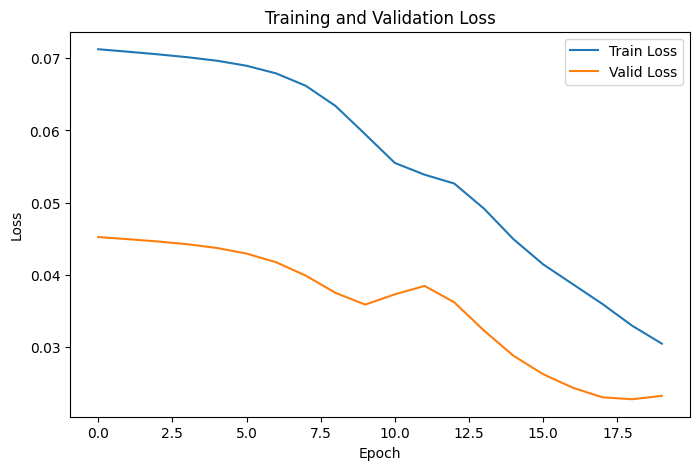

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [28]:
def show_reconstructions(model, dataloader, device, n=5):
    model.eval()

    images = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)

    images = images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    plt.figure(figsize=(12, 5))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i][0], cmap='gray')
        plt.axis('off')
        plt.title('Oryginał')

        plt.subplot(2, n, n + i + 1)
        plt.imshow(outputs[i][0], cmap='gray')
        plt.axis('off')
        plt.title('Rekonstrukcja')

    plt.tight_layout()
    plt.show()

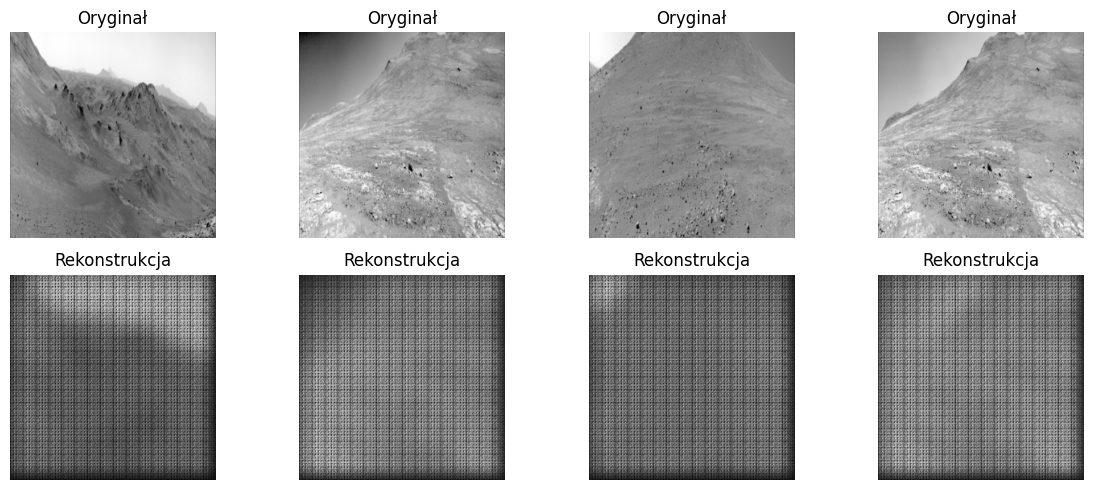

In [30]:
show_reconstructions(model, valid_loader, device, n=4)